In [4]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
#edge_options.add_argument('--headless')
edge_options.add_argument("--disable-images")  # Disable images
edge_options.add_argument("--disable-javascript")  # Disable JavaScript
edge_options.add_argument("--disable-plugins")  # Disable plugins
edge_options.add_argument("--disable-extensions")  # Disable extensions
edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")


In [2]:
url='https://www.car.info/en-se/brands?page=0'

In [3]:
driver.get(url)

In [4]:
all_car_urls={}
count_same=0
count_previous=0

while True:
    car_urls={e.find_element(By.CSS_SELECTOR,'a').get_attribute('href') : e.find_element(By.CSS_SELECTOR, 'div[class="tooltip_box tooltip_topright small no_click"]').text
              for e in driver.find_elements(By.CSS_SELECTOR, 'div[class="brand_item list_item mx-2"]')}
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    all_car_urls.update(car_urls)
    all_car_urls = {k: v for k, v in all_car_urls.items() if v not in set()}
    if any([v=='0' for v in all_car_urls.values()]):
        break

    if len(all_car_urls) == count_previous:
        count_same+=1
    else:
        count_same=0

    if count_same==5:
        break

    time.sleep(3)

    print(f'{len(all_car_urls)}, {count_previous}, {count_same}', end='\r')

400, 0, 0

In [65]:
all_data=[]

for i, (car_url, car_count) in enumerate(all_car_urls.items(),start=1):
    driver.get(car_url)

    try:
        expand_buttons=driver.find_elements(By.CSS_SELECTOR, 'div[type="button"][class="btn btn_expand btn-grey"]')
        for expand_button in expand_buttons:
            expand_button.click()
            time.sleep(2)
    except:
        None


    html=driver.page_source
    soup=BeautifulSoup(html)
    
    table_data = [
        [td.get_text("|", strip=True).split('|')[0] for td in tr.select("td")]
        for tr in soup.select("table.table.ci-table.table-md.table-striped.mb-2 tr")
    ]
    table_data=[row for row in table_data if len(row)==8]

    dict={'Car URL':car_url, 'Car Count':car_count, 'Table Data':table_data}
    all_data.append(dict)

    print(f'{i}/{len(all_car_urls)}',end='\r')

    

440/440

In [5]:
#pickle.dump(all_data, open('SE_cars.pickle','wb'))
all_data=pickle.load( open('SE_cars.pickle','rb'))

In [6]:
all_rows=[]

for i, dict_ in enumerate(all_data,start=1):
    car_brand=dict_['Car URL'].split('/')[-1]
    table_data=dict_['Table Data']
    for row in table_data:
        row.insert(0, car_brand)
        all_rows.append(row)

    print(f'{i}/{len(all_data)}',end='\r')

440/440

In [7]:
df=pd.DataFrame(all_rows,columns=['brand', 'model','year','type','chasis','seats','registered','for_sale','average_price'])

In [8]:
df['seats']=df['seats'].apply(lambda x:x.split('-')[0]).apply(pd.to_numeric)
df['registered']=df['registered'].apply(lambda x:x.replace(',','')).apply(pd.to_numeric)
df['for_sale']=df['for_sale'].apply(lambda x:x.replace(',','')).apply(pd.to_numeric)
df['average_price']=df['average_price'].apply(lambda x:x.replace(',','')).apply(pd.to_numeric)

In [9]:
df

,brand,model,year,type,chasis,seats,registered,for_sale,average_price
0,volvo,EC40,2025 -,Electric,SUV,5.0,4794.0,140.0,539750.0
1,volvo,EM90,2024 -,Electric,MPV,6.0,NaN,NaN,NaN
2,volvo,ES90,2025 -,Electric,Hatchback,5.0,459.0,27.0,999900.0
3,volvo,EX30,2024 -,Electric,SUV,5.0,13015.0,367.0,439500.0
4,volvo,EX40,2025 -,Electric,SUV,5.0,14105.0,299.0,504350.0
...,...,...,...,...,...,...,...,...,...
6611,aeolus,Yixuan Max,2021 -,P,Sedan,NaN,NaN,NaN,NaN
6612,aeolus,AX3,2018 - 2020,P,Hatchback,NaN,NaN,NaN,NaN
6613,aeolus,AX5,2016 - 2020,P,SUV,NaN,NaN,NaN,NaN
6614,aeolus,E60,2016 - 2021,Electric,Sedan,NaN,NaN,NaN,NaN


In [10]:
#population of sweden (as of Feb 2026)=10.7 mln
#total families in Sweden = 4.9 mln

In [11]:
print('count of registered cars and count of cars for sale in Sweden')
print(df['registered'].sum())
print(df['for_sale'].sum())

count of registered cars and count of cars for sale in Sweden
7416541.0
134562.0


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

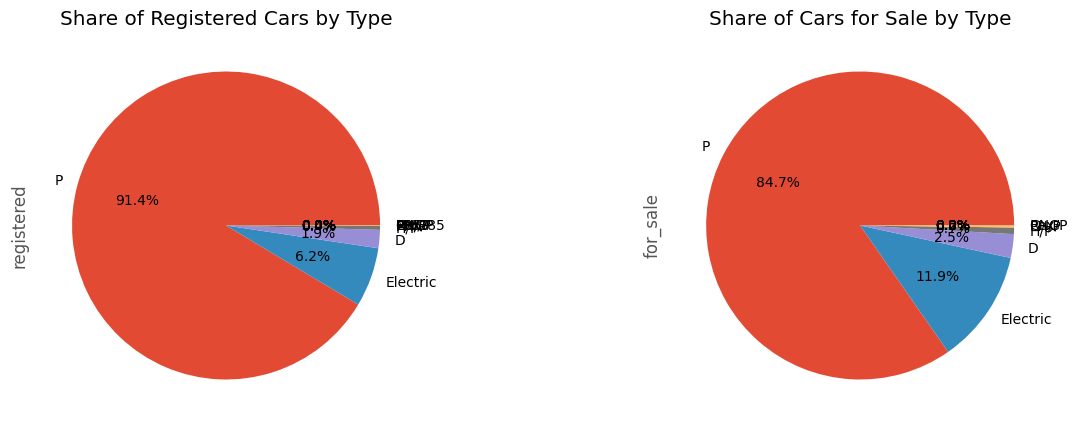

In [13]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
grouped_registered=df.groupby('type')['registered'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Registered Cars by Type')
grouped_forsale=df.groupby('type')['for_sale'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax2, title='Share of Cars for Sale by Type')
plt.show()


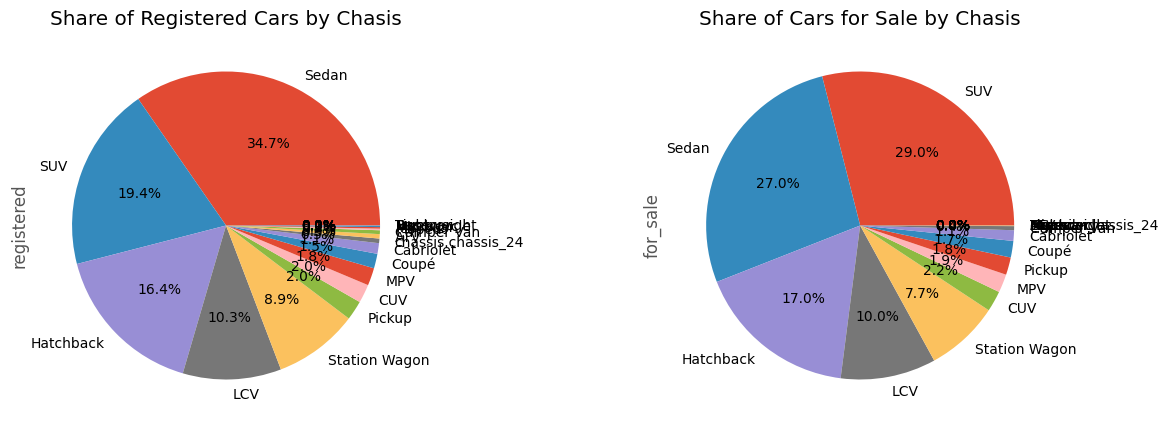

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
grouped_registered=df.groupby('chasis')['registered'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Registered Cars by Chasis')
grouped_forsale=df.groupby('chasis')['for_sale'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax2, title='Share of Cars for Sale by Chasis')
plt.show()


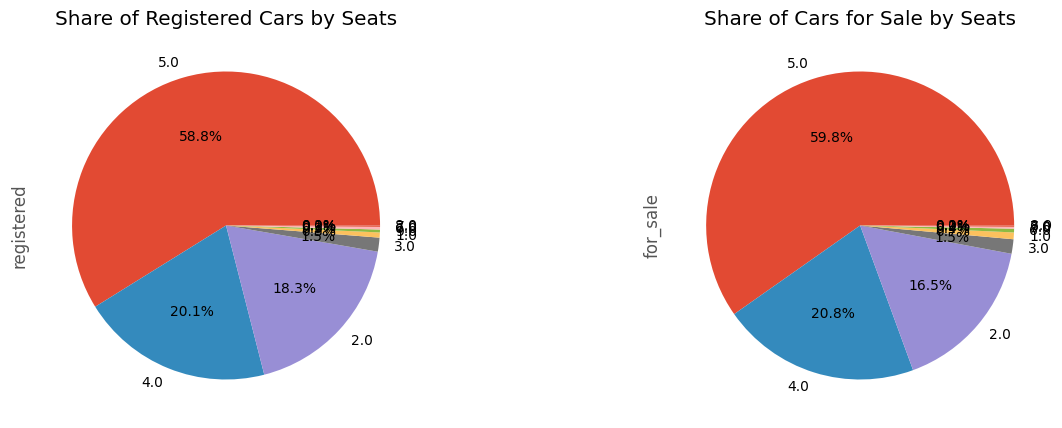

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
grouped_registered=df.groupby('seats')['registered'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Registered Cars by Seats')
grouped_forsale=df.groupby('seats')['for_sale'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax2, title='Share of Cars for Sale by Seats')
plt.show()


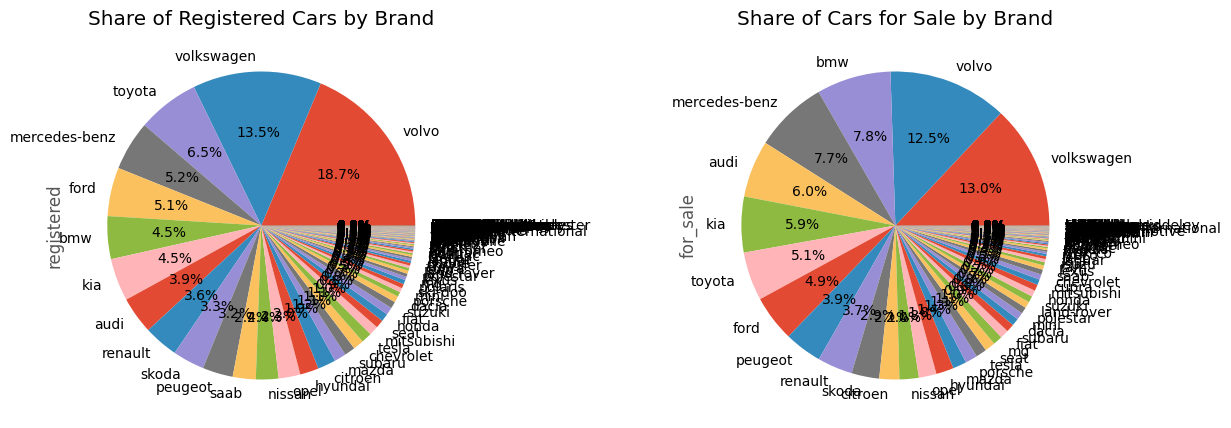

In [16]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
grouped_registered=df.groupby('brand')['registered'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Registered Cars by Brand')
grouped_forsale=df.groupby('brand')['for_sale'].sum().sort_values(ascending=False).plot.pie(autopct='%1.1f%%', ax=ax2, title='Share of Cars for Sale by Brand')
plt.show()


In [17]:
(df['for_sale']*df['average_price']).sum()/10**9*0.11

#approximate value (billion $) of the cars for sale

np.float64(3.31069848945)

In [18]:
(df['registered']*df['average_price']).sum()/10**9*0.11

#approximate value (billion $) of the registered cars

np.float64(130.06222438176)